<a href="https://colab.research.google.com/github/lricci03/Hands-on-ML/blob/main/c9/c9_ex10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# from sklearn.datasets import fetch_covtype
import numpy as np

In [ ]:
from sklearn.datasets import fetch_openml

# Download from OpenML instead of Figshare
covtype = fetch_openml(
    name="covertype",
    version=3,
    as_frame=True
)

X = covtype.data
y = covtype.target

print(X.shape)
print(y.shape)

HTTPError: HTTP Error 504: Gateway Time-out

In [ ]:
from sklearn.datasets import fetch_covtype

# Replace fetch_openml with the optimized scikit-learn loader
covtype = fetch_covtype(as_frame=True)

# Your existing logic remains exactly the same
X = covtype.data
y = covtype.target

print(X.shape)
print(y.shape)


(581012, 54)
(581012,)


In [ ]:
print(y.dtype)
print(X.dtypes)
y = y.astype(int)
X = X.astype(float)
print(y.dtype)
X.dtypes.value_counts()

int32
Elevation                             float64
Aspect                                float64
Slope                                 float64
Horizontal_Distance_To_Hydrology      float64
Vertical_Distance_To_Hydrology        float64
Horizontal_Distance_To_Roadways       float64
Hillshade_9am                         float64
Hillshade_Noon                        float64
Hillshade_3pm                         float64
Horizontal_Distance_To_Fire_Points    float64
Wilderness_Area_0                     float64
Wilderness_Area_1                     float64
Wilderness_Area_2                     float64
Wilderness_Area_3                     float64
Soil_Type_0                           float64
Soil_Type_1                           float64
Soil_Type_2                           float64
Soil_Type_3                           float64
Soil_Type_4                           float64
Soil_Type_5                           float64
Soil_Type_6                           float64
Soil_Type_7                 

,count
float64,54


In [ ]:
X.dtypes.value_counts()

,count
float64,54


In [ ]:
import math

train_threshold = math.floor(len(X)*0.8)
X_train, y_train = X[:train_threshold], y[:train_threshold]
X_test, y_test = X[train_threshold:], y[train_threshold:]

In [ ]:
print(train_threshold)

464809


The train set has 464'809 instances, the test set has 116'203 instances

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        early_stopping=True,
        random_state=42
    ))
])

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# create parameter grid for the hidden layers (no of layers and of neurons/layer)
# create parameter grid for activation functions (relu and logistic)

from itertools import product

hidden_layer_sizes = [
    (100,),
    (50,100),
    (50,50,50),
]
activation_fcts = [
    'relu',
    'logistic'
]

param_grid = {'mlp__hidden_layer_sizes':hidden_layer_sizes, 'mlp__activation': activation_fcts}
rnd_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy',n_jobs=-1)

In [ ]:
rnd_search.fit(X_train[:100000],y_train[:100000])
print(rnd_search.best_score_)
print(rnd_search.best_params_)

0.7115512359299511
{'mlp__activation': 'logistic', 'mlp__hidden_layer_sizes': (100,)}


In [ ]:
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(100,),activation='logistic', early_stopping=True, verbose=True,
        random_state=42
    ))
])

In [ ]:
best_model.fit(X_train[:250000],y_train[:250000])

Iteration 1, loss = 0.64279195
Validation score: 0.760120
Iteration 2, loss = 0.54147076
Validation score: 0.771200
Iteration 3, loss = 0.51628847
Validation score: 0.782120
Iteration 4, loss = 0.49491677
Validation score: 0.789160
Iteration 5, loss = 0.47836182
Validation score: 0.793840
Iteration 6, loss = 0.46521094
Validation score: 0.799720
Iteration 7, loss = 0.45327964
Validation score: 0.802200
Iteration 8, loss = 0.44297431
Validation score: 0.807240
Iteration 9, loss = 0.43339210
Validation score: 0.810520
Iteration 10, loss = 0.42489794
Validation score: 0.813040
Iteration 11, loss = 0.41738515
Validation score: 0.817080
Iteration 12, loss = 0.41015605
Validation score: 0.820680
Iteration 13, loss = 0.40380510
Validation score: 0.824560
Iteration 14, loss = 0.39747534
Validation score: 0.829960
Iteration 15, loss = 0.39179137
Validation score: 0.830800
Iteration 16, loss = 0.38623384
Validation score: 0.834120
Iteration 17, loss = 0.38108464
Validation score: 0.837960
Iterat

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(activation='logistic', early_stopping=True,
                               random_state=42, verbose=True))])

In [ ]:
best_model_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(50,50,50), activation='logistic', early_stopping=True, verbose=True,
        random_state=42
    ))
])

In [ ]:
best_model_2.fit(X_train[:250000],y_train[:250000])

Iteration 1, loss = 0.75234828
Validation score: 0.759360
Iteration 2, loss = 0.56514187
Validation score: 0.766840
Iteration 3, loss = 0.54071853
Validation score: 0.774120
Iteration 4, loss = 0.52179366
Validation score: 0.784000
Iteration 5, loss = 0.50219122
Validation score: 0.793320
Iteration 6, loss = 0.48394620
Validation score: 0.798720
Iteration 7, loss = 0.46949643
Validation score: 0.805880
Iteration 8, loss = 0.45606944
Validation score: 0.810760
Iteration 9, loss = 0.44315366
Validation score: 0.816160
Iteration 10, loss = 0.43192605
Validation score: 0.812880
Iteration 11, loss = 0.42277932
Validation score: 0.821920
Iteration 12, loss = 0.41602873
Validation score: 0.829400
Iteration 13, loss = 0.40938107
Validation score: 0.829840
Iteration 14, loss = 0.40448948
Validation score: 0.829800
Iteration 15, loss = 0.39986775
Validation score: 0.833320
Iteration 16, loss = 0.39557555
Validation score: 0.834920
Iteration 17, loss = 0.39136769
Validation score: 0.830760
Iterat

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(activation='logistic', early_stopping=True,
                               hidden_layer_sizes=(50, 50, 50), random_state=42,
                               verbose=True))])

In [ ]:
y_test_pred_2=best_model_2.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_test_pred_2)


0.6678829290121597

In [ ]:
y_test_pred=best_model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_test_pred)

0.6704560123232619

In [ ]:
best_model_3 = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(100,50), activation='logistic', early_stopping=True, verbose=True,
        random_state=42
    ))
])

In [ ]:
best_model_3.fit(X_train[:250000],y_train[:250000])

Iteration 1, loss = 0.69245622
Validation score: 0.755400
Iteration 2, loss = 0.54753462
Validation score: 0.770760
Iteration 3, loss = 0.51804667
Validation score: 0.782880
Iteration 4, loss = 0.49402188
Validation score: 0.790040
Iteration 5, loss = 0.47341085
Validation score: 0.796800
Iteration 6, loss = 0.45463275
Validation score: 0.806600
Iteration 7, loss = 0.43743359
Validation score: 0.814600
Iteration 8, loss = 0.42258528
Validation score: 0.819960
Iteration 9, loss = 0.41001319
Validation score: 0.823640
Iteration 10, loss = 0.39913194
Validation score: 0.830640
Iteration 11, loss = 0.39021412
Validation score: 0.835400
Iteration 12, loss = 0.38279463
Validation score: 0.836840
Iteration 13, loss = 0.37595035
Validation score: 0.835680
Iteration 14, loss = 0.36969888
Validation score: 0.842320
Iteration 15, loss = 0.36376197
Validation score: 0.845320
Iteration 16, loss = 0.35857328
Validation score: 0.848040
Iteration 17, loss = 0.35309266
Validation score: 0.848920
Iterat

Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(activation='logistic', early_stopping=True,
                               hidden_layer_sizes=(100, 50), random_state=42,
                               verbose=True))])

In [ ]:
y_test_pred_3=best_model_3.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_test_pred_3)

0.6959028596507836

In [ ]:
best_model_4 = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(200,), activation='logistic', early_stopping=True, verbose=True,
        random_state=42
    ))
])

In [ ]:
best_model_4.fit(X_train[:250000],y_train[:250000])

Iteration 1, loss = 0.61942113
Validation score: 0.760680
Iteration 2, loss = 0.53626954
Validation score: 0.768320
Iteration 3, loss = 0.51433848
Validation score: 0.781320
Iteration 4, loss = 0.49324307
Validation score: 0.785000
Iteration 5, loss = 0.47642938
Validation score: 0.792920
Iteration 6, loss = 0.46277067
Validation score: 0.796560
Iteration 7, loss = 0.44987576
Validation score: 0.802560
Iteration 8, loss = 0.43814811
Validation score: 0.808480
Iteration 9, loss = 0.42747665
Validation score: 0.812080
Iteration 10, loss = 0.41835809
Validation score: 0.819920
Iteration 11, loss = 0.41017699
Validation score: 0.823960
Iteration 12, loss = 0.40240345
Validation score: 0.826280
Iteration 13, loss = 0.39512116
Validation score: 0.829640
Iteration 14, loss = 0.38830493
Validation score: 0.834120
Iteration 15, loss = 0.38184583
Validation score: 0.839440
Iteration 16, loss = 0.37593976
Validation score: 0.838880
Iteration 17, loss = 0.36987579
Validation score: 0.844080
Iterat

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(activation='logistic', early_stopping=True,
                               hidden_layer_sizes=(200,), random_state=42,
                               verbose=True))])

In [ ]:
y_test_pred_4=best_model_4.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_test_pred_4)

0.6996807311343081

In [ ]:
mlp_clf = MLPClassifier(
        hidden_layer_sizes=(200,), activation='logistic', early_stopping=True, verbose=True,
        random_state=42
)

Same parameters for MLP as best_model_4 but without scaling

In [ ]:
mlp_clf.fit(X_train[:250000],y_train[:250000])

Iteration 1, loss = 0.81021021
Validation score: 0.719000
Iteration 2, loss = 0.69130460
Validation score: 0.747200
Iteration 3, loss = 0.64201643
Validation score: 0.747560
Iteration 4, loss = 0.62389425
Validation score: 0.753480
Iteration 5, loss = 0.61724183
Validation score: 0.754600
Iteration 6, loss = 0.61114001
Validation score: 0.754400
Iteration 7, loss = 0.60726254
Validation score: 0.755560
Iteration 8, loss = 0.60616748
Validation score: 0.747080
Iteration 9, loss = 0.59641770
Validation score: 0.741160
Iteration 10, loss = 0.59786338
Validation score: 0.755440
Iteration 11, loss = 0.59898445
Validation score: 0.759840
Iteration 12, loss = 0.58813581
Validation score: 0.760320
Iteration 13, loss = 0.59158449
Validation score: 0.754200
Iteration 14, loss = 0.59460029
Validation score: 0.763560
Iteration 15, loss = 0.59078227
Validation score: 0.758440
Iteration 16, loss = 0.58778583
Validation score: 0.745360
Iteration 17, loss = 0.58014669
Validation score: 0.748600
Iterat

MLPClassifier(activation='logistic', early_stopping=True,
              hidden_layer_sizes=(200,), random_state=42, verbose=True)

In [ ]:
best_model_5 = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(200,100), activation='logistic', early_stopping=True, verbose=True,
        random_state=42
    ))
])

In [ ]:
best_model_5.fit(X_train[:250000],y_train[:250000])

Iteration 1, loss = 0.64051050
Validation score: 0.770520
Iteration 2, loss = 0.52740195
Validation score: 0.786440
Iteration 3, loss = 0.49339844
Validation score: 0.793640
Iteration 4, loss = 0.47045468
Validation score: 0.798240
Iteration 5, loss = 0.45315925
Validation score: 0.805000
Iteration 6, loss = 0.43547747
Validation score: 0.815040
Iteration 7, loss = 0.41848652
Validation score: 0.817680
Iteration 8, loss = 0.40128359
Validation score: 0.830040
Iteration 9, loss = 0.38508836
Validation score: 0.839080
Iteration 10, loss = 0.37164575
Validation score: 0.844720
Iteration 11, loss = 0.35904233
Validation score: 0.849800
Iteration 12, loss = 0.34652346
Validation score: 0.858160
Iteration 13, loss = 0.33561437
Validation score: 0.865000
Iteration 14, loss = 0.32537879
Validation score: 0.867000
Iteration 15, loss = 0.31608261
Validation score: 0.865200
Iteration 16, loss = 0.30806187
Validation score: 0.875400
Iteration 17, loss = 0.30054467
Validation score: 0.873680
Iterat

Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(activation='logistic', early_stopping=True,
                               hidden_layer_sizes=(200, 100), random_state=42,
                               verbose=True))])

In [ ]:
y_test_pred_5=best_model_5.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_test_pred_5)

0.7277867180709621

In [ ]:
mlp = best_model_5.named_steps["mlp"]
print("Epochs trained:", mlp.n_iter_)
print("Best validation accuracy:", mlp.best_validation_score_)
print("Final training loss:", mlp.loss_)

Epochs trained: 151
Best validation accuracy: 0.9532
Final training loss: 0.09431549332467284


In [ ]:
train_acc = best_model_5.score(X_train[:250000], y_train[:250000])
test_acc = best_model_5.score(X_test, y_test)

print("Training accuracy:", train_acc)
print("Best validation accuracy:", mlp.best_validation_score_)
print("Test accuracy:", test_acc)

Training accuracy: 0.965524
Best validation accuracy: 0.9532
Test accuracy: 0.7277867180709621


In [ ]:
import numpy as np

Xtr = X_train[:250000]

mean_shift = np.abs(
    Xtr.mean(axis=0) - X_test.mean(axis=0)
) / Xtr.std(axis=0)

print("Largest mean shifts:")
print(np.sort(mean_shift)[-20:])

Largest mean shifts:
[0.3326818  0.34062037 0.35960103 0.36907088 0.44255337 0.45284083
 0.45607786 0.50247079 0.52616648 0.54845827 0.69490036 0.72334178
 0.7794565  0.79065692 0.80335477 1.18214889 1.95654316 2.03323145
 2.2934744  5.57152385]


In [ ]:
from collections import Counter

train_counts = Counter(y_train[:250000])
test_counts = Counter(y_test)

train_total = sum(train_counts.values())
test_total = sum(test_counts.values())

print("Training class percentages (descending):")
for cls, count in train_counts.most_common():
    print(f"Class {cls}: {100*count/train_total:.2f}%")

print("\nTest class percentages (descending):")
for cls, count in test_counts.most_common():
    print(f"Class {cls}: {100*count/test_total:.2f}%")

Training class percentages (descending):
Class 2: 62.40%
Class 1: 28.74%
Class 3: 2.36%
Class 5: 2.21%
Class 6: 1.96%
Class 7: 1.46%
Class 4: 0.87%

Test class percentages (descending):
Class 1: 44.80%
Class 2: 40.36%
Class 3: 6.62%
Class 7: 5.86%
Class 6: 2.17%
Class 5: 0.20%


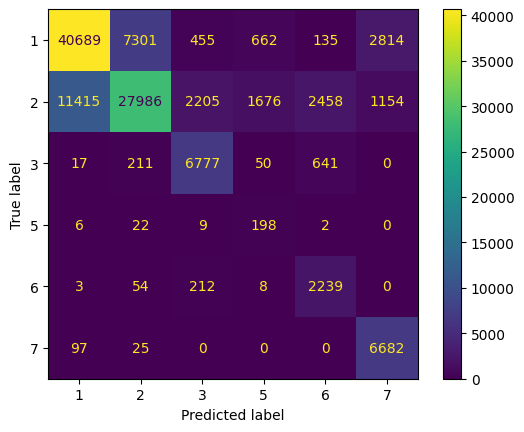

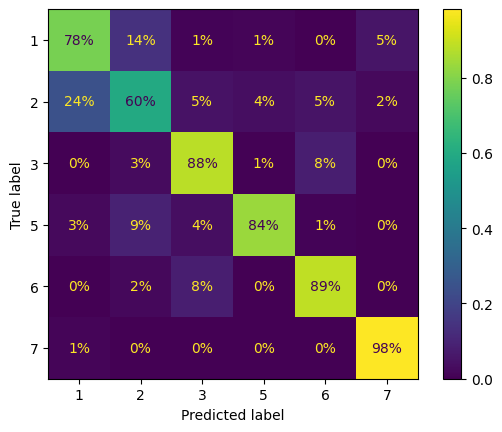

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_5)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_5, normalize='true',values_format='.0%')

In [ ]:
import numpy as np

for c in [1, 2]:
    train_c = X_train[:250000][y_train[:250000] == c]
    test_c = X_test[y_test == c]

    print(f"\nClass {c}")
    print("Train mean:", train_c.mean(axis=0)[:10])
    print("Test mean :", test_c.mean(axis=0)[:10])


Class 1
Train mean: Elevation                             3088.427957
Aspect                                 135.812288
Slope                                   10.629947
Horizontal_Distance_To_Hydrology       232.232313
Vertical_Distance_To_Hydrology          26.847217
Horizontal_Distance_To_Roadways       3903.729154
Hillshade_9am                          216.279335
Hillshade_Noon                         224.369677
Hillshade_3pm                          141.652060
Horizontal_Distance_To_Fire_Points    2421.272112
dtype: float64
Test mean : Elevation                             3151.925849
Aspect                                 179.974124
Slope                                   15.013735
Horizontal_Distance_To_Hydrology       304.544471
Vertical_Distance_To_Hydrology          51.923505
Horizontal_Distance_To_Roadways       1868.740722
Hillshade_9am                          205.853677
Hillshade_Noon                         220.760162
Hillshade_3pm                          147.421027
Ho

In [ ]:
import numpy as np

Xtr = X_train[:250000]

for c in [1, 2]:
    X_train_c = Xtr[y_train[:250000] == c]
    X_test_c = X_test[y_test == c]

    print(f"\nClass {c}")
    print("Number train:", len(X_train_c))
    print("Number test :", len(X_test_c))

    shift = np.abs(
        X_train_c.mean(axis=0) - X_test_c.mean(axis=0)
    ) / X_train_c.std(axis=0)

    print("Largest class-specific shifts:")
    print(np.sort(shift)[-10:])


Class 1
Number train: 71860
Number test : 52056
Largest class-specific shifts:
[nan nan nan nan nan nan nan nan nan nan]

Class 2
Number train: 155990
Number test : 46894
Largest class-specific shifts:
[2.92843112 3.06994459 3.09312434 9.17285175        nan        nan
        nan        nan        nan        nan]


In [ ]:
from collections import Counter

# True distribution
true_counts = Counter(y_test)

# Predicted distribution
pred_counts = Counter(y_test_pred_5)

print("True test distribution (%):")
total_true = len(y_test)
for cls, count in true_counts.most_common():
    print(f"Class {cls}: {100*count/total_true:.2f}%")

print("\nPredicted test distribution (%):")
total_pred = len(y_test_pred_5)
for cls, count in pred_counts.most_common():
    print(f"Class {cls}: {100*count/total_pred:.2f}%")

True test distribution (%):
Class 1: 44.80%
Class 2: 40.36%
Class 3: 6.62%
Class 7: 5.86%
Class 6: 2.17%
Class 5: 0.20%

Predicted test distribution (%):
Class 1: 44.94%
Class 2: 30.64%
Class 7: 9.16%
Class 3: 8.31%
Class 6: 4.71%
Class 5: 2.23%


In [ ]:
import numpy as np

Xtr = X_train[:250000]
ytr = y_train[:250000]

for c in [1, 2]:
    X_train_c = Xtr[ytr == c]
    X_test_c = X_test[y_test == c]

    shift = np.abs(
        X_train_c.mean(axis=0) - X_test_c.mean(axis=0)
    ) / X_train_c.std(axis=0)

    print(f"\nClass {c}")
    print("Largest shifts:")
    print(np.sort(shift)[-10:])


Class 1
Largest shifts:
[nan nan nan nan nan nan nan nan nan nan]

Class 2
Largest shifts:
[2.92843112 3.06994459 3.09312434 9.17285175        nan        nan
        nan        nan        nan        nan]


In [ ]:
best_model_6 = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(200,100,50), activation='logistic', early_stopping=True, verbose=True,
        random_state=42
    ))
])

In [ ]:
best_model_6.fit(X_train[:250000],y_train[:250000])

Iteration 1, loss = 0.66694456
Validation score: 0.762280
Iteration 2, loss = 0.54528019
Validation score: 0.772480
Iteration 3, loss = 0.51640786
Validation score: 0.783600
Iteration 4, loss = 0.49474770
Validation score: 0.794240
Iteration 5, loss = 0.47445530
Validation score: 0.797800
Iteration 6, loss = 0.45241509
Validation score: 0.806440
Iteration 7, loss = 0.43215738
Validation score: 0.810280
Iteration 8, loss = 0.41435612
Validation score: 0.825960
Iteration 9, loss = 0.39787860
Validation score: 0.825600
Iteration 10, loss = 0.38226948
Validation score: 0.843920
Iteration 11, loss = 0.36832450
Validation score: 0.849600
Iteration 12, loss = 0.35667038
Validation score: 0.854200
Iteration 13, loss = 0.34657017
Validation score: 0.857400
Iteration 14, loss = 0.33670904
Validation score: 0.859760
Iteration 15, loss = 0.32877313
Validation score: 0.863320
Iteration 16, loss = 0.32218221
Validation score: 0.864600
Iteration 17, loss = 0.31467730
Validation score: 0.861920
Iterat

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(activation='logistic', early_stopping=True,
                               hidden_layer_sizes=(200, 100, 50),
                               random_state=42, verbose=True))])

In [ ]:
y_test_pred_6=best_model_6.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_test_pred_6)

0.7165219486588126

In [ ]:
best_model_7 = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(200,100), activation='relu', early_stopping=True, verbose=True,
        random_state=42
    ))
])

In [ ]:
best_model_7.fit(X_train[:250000],y_train[:250000])

Iteration 1, loss = 0.51199648
Validation score: 0.812120
Iteration 2, loss = 0.41640460
Validation score: 0.830760
Iteration 3, loss = 0.37161437
Validation score: 0.853520
Iteration 4, loss = 0.34110555
Validation score: 0.859840
Iteration 5, loss = 0.31762753
Validation score: 0.873560
Iteration 6, loss = 0.29937666
Validation score: 0.878600
Iteration 7, loss = 0.28577849
Validation score: 0.872440
Iteration 8, loss = 0.27460617
Validation score: 0.883800
Iteration 9, loss = 0.26398948
Validation score: 0.883120
Iteration 10, loss = 0.25585156
Validation score: 0.887360
Iteration 11, loss = 0.24916641
Validation score: 0.892440
Iteration 12, loss = 0.24152249
Validation score: 0.897240
Iteration 13, loss = 0.23529424
Validation score: 0.899320
Iteration 14, loss = 0.23116541
Validation score: 0.901640
Iteration 15, loss = 0.22530518
Validation score: 0.900160
Iteration 16, loss = 0.22085032
Validation score: 0.905840
Iteration 17, loss = 0.21752747
Validation score: 0.905400
Iterat

Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(early_stopping=True,
                               hidden_layer_sizes=(200, 100), random_state=42,
                               verbose=True))])

In [ ]:
y_test_pred_7=best_model_7.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_test_pred_7)

0.688097553419447

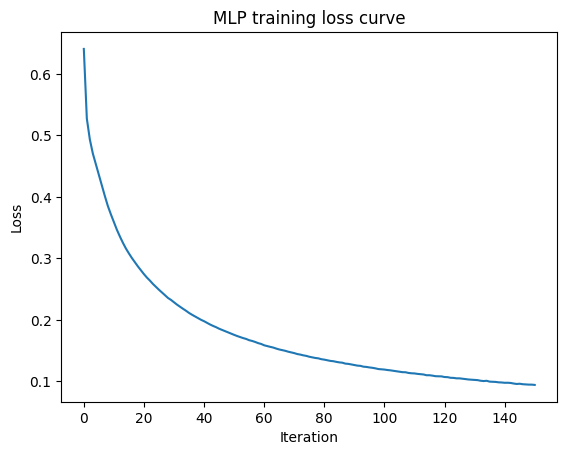

In [ ]:
model=best_model_5
mlp_clf_5 = model.named_steps['mlp']

import matplotlib.pyplot as plt

plt.plot(mlp_clf_5.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP training loss curve")
plt.show()

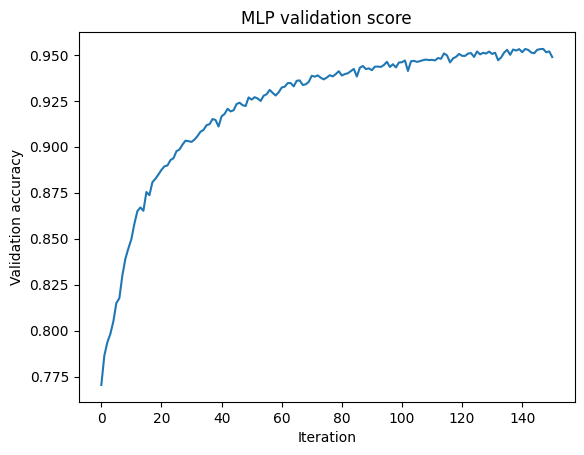

In [ ]:
plt.plot(mlp_clf_5.validation_scores_)
plt.xlabel("Iteration")
plt.ylabel("Validation accuracy")
plt.title("MLP validation score")
plt.show()

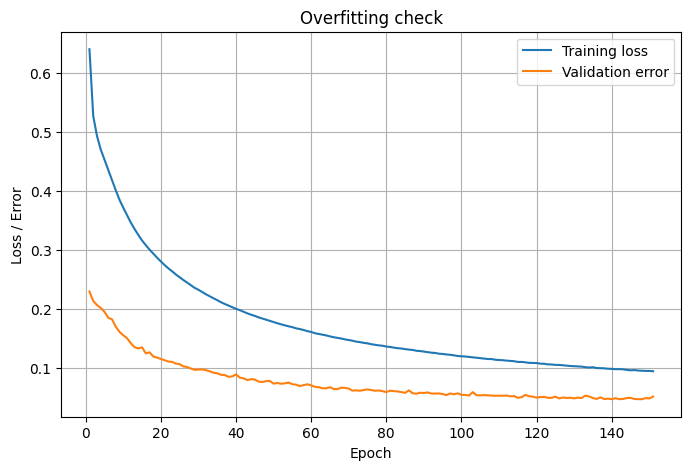

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


mlp = mlp_clf_5   # your fitted MLP

train_loss = np.array(mlp.loss_curve_)
val_error = 1 - np.array(mlp.validation_scores_)

epochs = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_loss, label="Training loss")
plt.plot(epochs, val_error, label="Validation error")

plt.xlabel("Epoch")
plt.ylabel("Loss / Error")
plt.title("Overfitting check")
plt.legend()
plt.grid()
plt.show()

In [ ]:
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(200,100), activation='logistic', verbose=True,
        random_state=42
    ))
])

In [ ]:
final_model.fit(X_train,y_train)

Iteration 1, loss = 0.66075475
Iteration 2, loss = 0.55024922
Iteration 3, loss = 0.50164629
Iteration 4, loss = 0.46370655
Iteration 5, loss = 0.43158495
Iteration 6, loss = 0.40590007
Iteration 7, loss = 0.38430878
Iteration 8, loss = 0.36561587
Iteration 9, loss = 0.34876688
Iteration 10, loss = 0.33438207
Iteration 11, loss = 0.32143066
Iteration 12, loss = 0.30950192
Iteration 13, loss = 0.29907005
Iteration 14, loss = 0.28931988
Iteration 15, loss = 0.28006392
Iteration 16, loss = 0.27165925
Iteration 17, loss = 0.26362342
Iteration 18, loss = 0.25664915
Iteration 19, loss = 0.24954748
Iteration 20, loss = 0.24352166
Iteration 21, loss = 0.23731055
Iteration 22, loss = 0.23149963
Iteration 23, loss = 0.22658855
Iteration 24, loss = 0.22153289
Iteration 25, loss = 0.21707171
Iteration 26, loss = 0.21260295
Iteration 27, loss = 0.20845665
Iteration 28, loss = 0.20458593
Iteration 29, loss = 0.20122862
Iteration 30, loss = 0.19753090
Iteration 31, loss = 0.19448684
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(activation='logistic',
                               hidden_layer_sizes=(200, 100), random_state=42,
                               verbose=True))])

In [ ]:
y_test_pred=final_model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_test_pred)

0.7133981050403174

In [ ]:
final_model.score(X_test,y_test)

0.7133981050403174

## Correct way to split the dataset to train and test

In [ ]:
from sklearn.model_selection import train_test_split
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    covtype.data, covtype.target, random_state=42)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        early_stopping=True,
        verbose=True,
        hidden_layer_sizes=(200,100,50),
        random_state=42
    ))
])

In [ ]:
model.fit(X_train_new[:250000],y_train_new[:250000])

Iteration 1, loss = 0.59059539
Validation score: 0.784360
Iteration 2, loss = 0.47448573
Validation score: 0.811200
Iteration 3, loss = 0.42179987
Validation score: 0.827680
Iteration 4, loss = 0.38675383
Validation score: 0.847000
Iteration 5, loss = 0.36191923
Validation score: 0.854440
Iteration 6, loss = 0.34208366
Validation score: 0.860360
Iteration 7, loss = 0.32492654
Validation score: 0.863640
Iteration 8, loss = 0.31188060
Validation score: 0.870040
Iteration 9, loss = 0.30023491
Validation score: 0.875440
Iteration 10, loss = 0.29105610
Validation score: 0.879480
Iteration 11, loss = 0.28225462
Validation score: 0.878400
Iteration 12, loss = 0.27553984
Validation score: 0.879680
Iteration 13, loss = 0.26795793
Validation score: 0.885400
Iteration 14, loss = 0.26212822
Validation score: 0.887080
Iteration 15, loss = 0.25739378
Validation score: 0.888680
Iteration 16, loss = 0.25045232
Validation score: 0.894400
Iteration 17, loss = 0.24556249
Validation score: 0.895960
Iterat

Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(early_stopping=True,
                               hidden_layer_sizes=(200, 100, 50),
                               random_state=42, verbose=True))])

In [ ]:
model.score(X_test_new,y_test_new)

0.9217090180581469